In [1]:
import numpy as np
import networkx as nx
import os

from dwave.inspector.adapters import enable_data_capture
from dwave.cloud.solver import StructuredSolver


from recover_dwave_inspector_data import recover_dwave_inspector_problems_from_runs
from graph_search_results import IterativeSearchGraphResults


%load_ext autoreload
%autoreload 2

In [2]:
graphs = np.load("../Tutorials/Power-law/resolution-1/graphs-1_m-1_p-0.1.npy", allow_pickle=True)
graphs = [g[0] for g in graphs]
graphs_110_160 = np.load("graphs/powerlaw_110-160/powerlaw_graphs_110-160.npy", allow_pickle=True).tolist()
graphs = graphs + graphs_110_160

In [3]:
results_dir = f"Power-law/resolution-1/graphs-1_m-1_p-0.1"
# os.makedirs(results_dir, exist_ok=True)

In [4]:
from Qommunity.searchers.utils import HierarchicalRunMetadata

graphs_results = {}

num_runs = 20
graph_sizes = np.arange(10, 160, 10).tolist()
base = f"./{results_dir}"


for g_size in graph_sizes:
    graphs_results_path_base =  base + f"/graph_size={g_size}/powerlaw_m=1_p=0.1"
    hierarchical_metadatas = []
    
    if g_size == 150:
        for iter in range(16):
            base_filename = f"{graphs_results_path_base}_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
        
        path = base + f"/graph_size={g_size}"
        for iter in range(3):
            base_filename = f"{path}-4runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
    else:
        for iter in range(num_runs):
            base_filename = f"{graphs_results_path_base}_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

    path = base + f"/graph_size={g_size}/"
    iterative_graph_results = IterativeSearchGraphResults(
        graph_ref = graphs[graph_sizes.index(g_size)],
        graph_size=g_size,
        communities = np.load(f"{path}/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True),
        modularities = np.load(f"{path}/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True),
        times = np.load(f"{path}/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True),
        division_modularities = np.load(f"{path}/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True),
        division_trees = np.load(f"{path}/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True),
        hierarchical_metadatas=hierarchical_metadatas
    )

    graphs_results[g_size] = iterative_graph_results

In [ ]:
# from saving_utils import parse_response_json
# import glob

# results = {}

# num_runs = 20
# graph_sizes = np.arange(10, 160, 10).tolist()
# rec_base = "recovery_dwave_inspector"
# base = f"./{results_dir}"


# for g_size in graph_sizes:
#     graphs_results_path_base = base + f"/graph_size={g_size}/{rec_base}/"
#     files = glob.glob(f"{graphs_results_path_base}/**/*_response.json", recursive=True)
#     responses = []

#     for file in files:
#         response_json = parse_response_json(file)
#         responses.append(response_json)

#     if g_size == 150:
#         files = glob.glob(f"{base}/graph_size={g_size}-4runs/{rec_base}/**/*_response.json", recursive=True)    

#     results[g_size] = responses

In [7]:
from saving_utils import parse_response_json #, deserialize_qubo_problem

In [8]:
base

'./Power-law/resolution-1/graphs-1_m-1_p-0.1'

In [108]:
response_obj = parse_response_json(f"{base}/graph_size=150/recovery_dwave_inspector/iter_0_problem_id=1f8c1fb9-2905-48ed-9a9d-d92e3069a57e_response.json")
# response_obj = parse_response_json(f"{base}/graph_size=10/recovery_dwave_inspector/iter_0_problem_id=35b6d2c9-1314-4b5c-b8b0-ae9b36dca10c_response.json")

In [109]:
from dwave.cloud.client import Client
from dwave.cloud.solver import StructuredSolver

solver_reconstructed = StructuredSolver(client=Client, data=response_obj.solver["data"])

In [ ]:
# iters = {}

# for iter in range(19):
#     hmiter = graphs_results[150].hierarchical_metadatas[iter]
#     pr_sizes = {}
#     for hmrun in hmiter:
#         pr_id = hmrun.problem_id
#         sampleset = hmrun.dwave_sampleset
#         variables = list(sampleset.variables)
#         qpu_access_times = hmrun.dwave_sampleset_metadata.qpu_access_time_us
#         pr_sizes[pr_id] = {"variables": variables, "num_vars": len(variables), "pr_id": pr_id, "qpu_access_times": qpu_access_times}
#     iters[iter] = pr_sizes
    

In [ ]:
# base_dir = f"./{results_dir}/graph_size=150/recovery_dwave_inspector"
# response_obj = parse_response_json(f"{base}/graph_size=150/recovery_dwave_inspector
# # response_obj = parse_response_json(f"{base}/graph_size=10/recovery_dwave_inspector/iter_0_problem_id=35b6d2c9-1314-4b5c-b8b0-ae9b36dca10c_response.json")

In [118]:
vars(response_obj).keys()

dict_keys(['answer_data', 'clock_diff', 'data_id', 'energies', 'id', 'label', 'num_occurrences', 'parse_time', 'problem_type', 'remote_status', 'return_matrix', 'samples', 'sampleset', 'solver', 'time_created', 'time_received', 'time_resolved', 'time_solved', 'timing', 'variables'])

In [128]:
response_obj.sampleset

SampleSet(rec.array([([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 1.14908083e-14, 30),
           ([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 1.32671651e-14, 68),
           ([1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0], 7.98561151e-01,  1),
           ([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1], 9.49640288e-01,  1)],
          dtype=[('sample', 'i1', (16,)), ('energy', '<f8'), ('num_occurrences', '<i8')]), Variables([150, 165, 180, 195, 210, 225, 240, 255, 2940, 2955, 2970, 2985, 3000, 3015, 3030, 3045]), {'timing': {'qpu_sampling_time': 7322.0, 'qpu_anneal_time_per_sample': 20.0, 'qpu_readout_time_per_sample': 32.64, 'qpu_access_time': 23249.56, 'qpu_access_overhead_time': 435.44, 'qpu_programming_time': 15927.56, 'qpu_delay_time_per_sample': 20.58, 'total_post_processing_time': 1.0, 'post_processing_overhead_time': 1.0}, 'problem_id': '1f8c1fb9-2905-48ed-9a9d-d92e3069a57e', 'problem_label': 'iter_0_n=140_comm_hash=6567673700307293525_-652695734824921894'}, 'BI

In [121]:
response_obj.__dict__["variables"]

[150,
 165,
 180,
 195,
 210,
 225,
 240,
 255,
 2940,
 2955,
 2970,
 2985,
 3000,
 3015,
 3030,
 3045]

In [124]:
response_obj.__dict__["timing"]["qpu_access_time"]

23249.56

In [111]:
pr_sizes = []
qputs = []
estimated_qputs = []
diffs = []
rel_diffs = []

for pr_id, runs in iters[0].items():
    pr_size = runs["num_vars"]
    print(f"Problem size: {pr_size}")
    qput = runs["qpu_access_times"]
    estimated_qput = round(solver_reconstructed.estimate_qpu_access_time(pr_size, num_reads=100), 2)
    diff = abs(round(estimated_qput - qput, 2))
    rel_diff = round(diff / qput * 100, 2)
    
    pr_sizes.append(pr_size)
    qputs.append(qput)
    estimated_qputs.append(estimated_qput)
    diffs.append(diff)
    rel_diffs.append(rel_diff)

    print(f"{pr_size}\t {qput}\t  {estimated_qput}\t {diff} \t{rel_diff}%")

Problem size: 150
150	 36100.36	  31727.96	 4372.4 	12.11%
Problem size: 71
71	 27060.36	  29608.29	 2547.93 	9.42%
Problem size: 41
41	 25055.16	  28285.73	 3230.57 	12.89%
Problem size: 14
14	 23746.36	  26167.94	 2421.58 	10.2%
Problem size: 7
7	 23170.76	  25074.3	 1903.54 	8.22%
Problem size: 2
2	 22444.76	  22831.04	 386.28 	1.72%
Problem size: 5
5	 23010.76	  24607.92	 1597.16 	6.94%
Problem size: 7
7	 23250.76	  25074.3	 1823.54 	7.84%
Problem size: 6
6	 23090.76	  24855.76	 1765.0 	7.64%
Problem size: 27
27	 24296.36	  27394.3	 3097.94 	12.75%
Problem size: 4
4	 22754.76	  24319.54	 1564.78 	6.88%
Problem size: 23
23	 24229.16	  27076.09	 2846.93 	11.75%
Problem size: 30
30	 24364.76	  27610.44	 3245.68 	13.32%
Problem size: 16
16	 23780.76	  26401.25	 2620.49 	11.02%
Problem size: 8
8	 23250.76	  25270.53	 2019.77 	8.69%
Problem size: 3
3	 22720.76	  23717.71	 996.95 	4.39%
Problem size: 2
2	 22444.76	  22831.04	 386.28 	1.72%
Problem size: 5
5	 23010.76	  24607.92	 1597.16 	

array([ -389.48, -1567.98, -1567.98, -1768.2 , -2366.25])

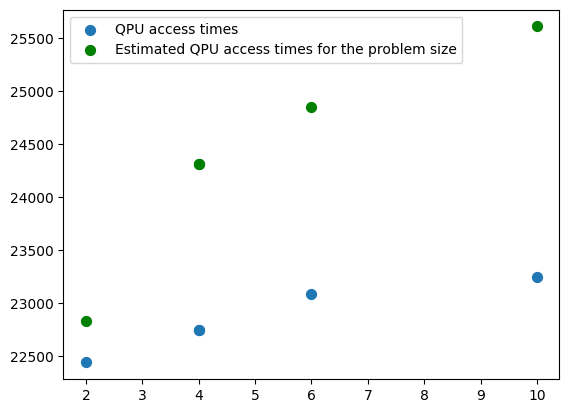

In [99]:
import matplotlib.pyplot as plt


d = tuple((ps, qt) for ps, qt in zip(pr_sizes, qputs))
xy = sorted(d, key=lambda x: x[0])
xs = [x[0] for x in xy]
ys = [x[1] for x in xy]

e = tuple((ps, qt) for ps, qt in zip(pr_sizes, estimated_qputs))
xye = sorted(e, key=lambda x: x[0])
xse = [x[0] for x in xye]
yse = [x[1] for x in xye]

errors = np.array(ys) - np.array(yse)

xvals = np.linspace(1, 200, 100)
yinterp = np.interp(xvals, xs, ys)
plt.scatter(xs, ys, label="QPU access times", s=50)
plt.scatter(xse, yse, color='green', label="Estimated QPU access times for the problem size", s=50)
plt.legend()
# plt.scatter(xvals, yinterp, color='red', label="Interpolated", s=10)
# relative_errors = [100 * abs(yi - ye) / yi for yi, ye in zip(ys, yse)]
errors
# xsvals = np.linspace(1, 60, 60)
# yinterp = np.interp(xsvals, xs, relative_errors)
# plt.scatter(xs, relative_errors, color='orange', label="Relative error", s=50)
# plt.scatter(xsvals, yinterp, color='green', label="Interpolated", s=10)
# plt.xticks(xsvals);

114279.40000000001
121939.29204095496


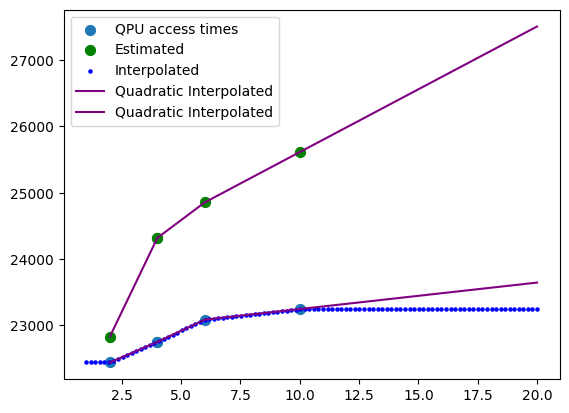

In [107]:
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


d = tuple((ps, qt) for ps, qt in zip(pr_sizes, qputs))
xy = sorted(d, key=lambda x: x[0])
xs = [x[0] for x in xy]
ys = [x[1] for x in xy]

e = tuple((ps, qt) for ps, qt in zip(pr_sizes, estimated_qputs))
xye = sorted(e, key=lambda x: x[0])
xse = [x[0] for x in xye]
yse = [x[1] for x in xye]
print(np.sum(ys))
print(np.sum([solver_reconstructed.estimate_qpu_access_time(pr_size, num_reads=100) for pr_size in pr_sizes]))

errors = np.array(ys) - np.array(yse)

xvals = np.linspace(1, 20, 100)
yinterp = np.interp(xvals, xs, ys)
plt.scatter(xs, ys, label="QPU access times", s=50)
plt.scatter(xse, yse, color='green', label="Estimated", s=50)
plt.scatter(xvals, yinterp, color='blue', label="Interpolated", s=5)
relative_errors = [100 * abs(yi - ye) / yi for yi, ye in zip(ys, yse)]

xsvals = np.linspace(2, 20, 100)
yinterp = np.interp(xsvals, xse, yse)

xs = np.array(xs)
ys = np.array(ys)
_, idx = np.unique(xs, return_index=True)
xs_unique = xs[idx]
ys_unique = ys[idx]
f = interp1d(xs_unique, ys_unique, kind='linear', fill_value="extrapolate")
fnew = f(xsvals)
plt.plot(xsvals, fnew, color='purple', label="Quadratic Interpolated")

xse = np.array(xse)
yse = np.array(yse)
_, idx = np.unique(xse, return_index=True)
xse_unique = xse[idx]
yse_unique = yse[idx]
f = interp1d(xse_unique, yse_unique, kind='linear', fill_value="extrapolate")
fnew = f(xsvals)
plt.plot(xsvals, fnew, color='purple', label="Quadratic Interpolated")

# plt.scatter(xs, relative_errors, color='orange', label="Relative error", s=50)
# plt.scatter(xsvals, yinterp, color='green', label="Interpolated", s=5)
# plt.xticks(xsvals);
plt.legend()

In [ ]:
relative_errors = [100 * abs(yi - ye) / yi for yi, ye in zip(ys, yse)]
relative_differences = []

In [196]:
qpu_access_times_first_div = [hm.dwave_sampleset_metadata.qpu_access_time_us[0] for hm in graphs_results[20].hierarchical_metadatas]
qpu_access_times_first_div


[np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16),
 np.float64(23913.16)]

In [ ]:
qpu_access_times_first_div = [hm.dwave_sampleset_metadata.qpu_access_time_us[0] for hm in graphs_results[20].hierarchical_metadatas]
qpu_access_times_first_div

In [33]:
from dwave.cloud.client import Client
from dwave.cloud.solver import StructuredSolver


solver_reconstructed = StructuredSolver(client=Client, data=response_obj.solver["data"])
solver_reconstructed

StructuredSolver(name='Advantage_system6.4', graph_id='01dae5a273')

In [129]:
solver_reconstructed.estimate_qpu_access_time(60, num_reads=100)

np.float64(29183.401872283364)

In [186]:
problem_timing_data = solver_reconstructed.properties["problem_timing_data"]
typical_programming_time = problem_timing_data['typical_programming_time']
ra_with_reinit_prog_time_delta = problem_timing_data['reverse_annealing_with_reinit_prog_time_delta']
ra_without_reinit_prog_time_delta = problem_timing_data['reverse_annealing_without_reinit_prog_time_delta']
default_programming_thermalization = problem_timing_data['default_programming_thermalization']
default_annealing_time = problem_timing_data['default_annealing_time']
readout_time_model = problem_timing_data['readout_time_model']
readout_time_model_parameters = problem_timing_data['readout_time_model_parameters']
qpu_delay_time_per_sample = problem_timing_data['qpu_delay_time_per_sample']
ra_with_reinit_delay_time_delta = problem_timing_data['reverse_annealing_with_reinit_delay_time_delta']
ra_without_reinit_delay_time_delta = problem_timing_data['reverse_annealing_without_reinit_delay_time_delta']
decorrelation_max_nominal_anneal_time = problem_timing_data['decorrelation_max_nominal_anneal_time']
decorrelation_time_range = problem_timing_data['decorrelation_time_range']
default_readout_thermalization = problem_timing_data['default_readout_thermalization']


num_qubits = 20
num_reads = 100

ra_programming_time = 0
ra_delay_time = 0
annealing_time = 20
readout_thermalization = default_readout_thermalization

reduce_intersample_correlation = False
anneal_schedule = None
reinitilize_state = False
reinitialize_state = None
programming_thermalization = None

if anneal_schedule and anneal_schedule[0][1] == 1:
    if reinitialize_state:
        ra_programming_time = ra_with_reinit_prog_time_delta
        ra_delay_time = ra_with_reinit_delay_time_delta
    else:
        ra_programming_time = ra_without_reinit_prog_time_delta
        ra_delay_time = ra_without_reinit_delay_time_delta

if programming_thermalization:
    programming_thermalization_time = programming_thermalization
else:
    programming_thermalization_time = default_programming_thermalization

programming_time = typical_programming_time + ra_programming_time + \
                    programming_thermalization_time


programming_time = typical_programming_time + ra_programming_time + \
                    programming_thermalization_time

anneal_time = default_annealing_time
if annealing_time:
    anneal_time = annealing_time
elif anneal_schedule:
    anneal_time = anneal_schedule[-1][0]


n = len(readout_time_model_parameters)
if n % 2:
    pass

q = readout_time_model_parameters[:n//2]
t = readout_time_model_parameters[n//2:]
if readout_time_model == 'pwl_log_log':
    readout_time = pow(10, np.interp(np.emath.log10(num_qubits), q, t))
elif readout_time_model == 'pwl_linear':
    readout_time = np.interp(num_qubits, q, t)
else:
    pass

if readout_thermalization:
    readout_thermalization_time = readout_thermalization
else:
    readout_thermalization_time = default_readout_thermalization

decorrelation_time = 0
if reduce_intersample_correlation:
    r_min = decorrelation_time_range[0]
    r_max = decorrelation_time_range[1]
    decorrelation_time = anneal_time/decorrelation_max_nominal_anneal_time * (r_max - r_min) + r_min

sampling_time_per_read = anneal_time + readout_time + qpu_delay_time_per_sample + \
    ra_delay_time + max(readout_thermalization_time, decorrelation_time)

sampling_time = num_reads * sampling_time_per_read

sampling_time + programming_time

np.float64(26808.932617624603)

In [78]:
len(response_obj.variables)

60

In [66]:
for i in range(20):
    print(graphs_results[20].qpu_access_times_us[i][0])

23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16
23913.16


In [63]:
graphs_results[20].hierarchical_metadatas[18].dwave_sampleset_metadata.qpu_access_time_us

array([23913.16, 23247.16, 23087.56, 22717.56, 22717.56, 22751.56,
       23247.56, 23061.56, 23061.56])

In [11]:
from Qommunity.searchers.utils import HierarchicalRunMetadata
import pickle
import json
import glob

recovery_graph_results = {}

num_runs = 20
graph_sizes = np.arange(10, 160, 10).tolist()

base_dir_external_disk = r"D:/Qommunity-chain_breaks"
PL_BASE = "powerlaw_m=1_p=0.1"
REC_BASE = "recovery_dwave_inspector"


base = f"{base_dir_external_disk}"
problem_ids_json = {}

for g_size in graph_sizes[1:2]:
    base += f"/graph_size={g_size}/{REC_BASE}/"
    problem_ids = graphs_results[g_size].problem_ids
    for iter in range(num_runs):
        # response_files = glob.glob(
        #     f"{base}/***response.json",
        #     recursive=True
        # )
        # print(len(response_files))

        for pr_id in problem_ids[iter]:
            base_filename = f"{base}iter_{iter}_problem_id={pr_id}_response.json"
            # print(base_filename in response_files)
            with open(base_filename, "rb") as f:
                pro_ids_json = json.load(f)
            problem_ids_json[pr_id] = pro_ids_json

In [ ]:
problem_ids_json

In [270]:
problem.solver.estimate_qpu_access_time(160)

np.float64(15400.743174412739)

In [280]:
import base64
import hashlib
import json
import os
import requests
import struct
from urllib.parse import urlencode
SAPI_HOME = "https://na-west-1.cloud.dwavesys.com/sapi/v2"
# Replace with your API token
SAPI_TOKEN = "jszS-032644055696b82b3179a8e30fc4d740e820bce1"
session = requests.Session()
session.headers = {'X-Auth-Token': SAPI_TOKEN,
                   'Content-type': 'application/json'}